In [ ]:
!pip install tensorflow pandas scikit-learn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
from google.colab import files
uploaded = files.upload()  # Opens a file chooser dialog

# The uploaded variable will be a dictionary where keys are filenames and values are file contents.
# Assuming you uploaded a single file, you can get the filename like this:
for fn in uploaded.keys():
  file_path = fn

# Now you can use the file_path variable in the next cell to read the CSV
print(f"File '{file_path}' uploaded.")

In [ ]:
import pandas as pd

df = pd.read_csv(file_path)

print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Patient_ID  Age  Gender  Height_cm  Weight_kg Employment_Sector  \
0           1   56  Female        174         81        Government   
1           2   46    Male        178         88        Government   
2           3   32  Female        164         98           Private   
3           4   60    Male        150         81        Government   
4           5   25  Female        174         53        Government   

            Job_Type  Work_Hours_per_Week Work_Stress_Level Healthcare_Access  \
0      Civil Servant                   39              High         Excellent   
1     Police Officer                   36              High         Excellent   
2    IT Professional                   47               Low         Excellent   
3  Healthcare Worker                   45              High              Good   
4          Inspector                   39              High         Excellent   

   ... Blood_pressure_dia  Cholesterol    BMI  Gen_Risk_Diabetes  \
0  ... 

In [ ]:
df = df.drop(columns=['Gender', 'Gen_Risk_Diabetes','Gen_Risk_Heart',"BP", 'Medication','Unnamed: 21', 'Employment_Sector', 'Job_Type', 'Work_Hours_per_W'], errors='ignore')

In [ ]:
df = df.drop(columns=['Gender', 'Gen_Risk_Diabetes','Gen_Risk_Heart',"BP", 'Medication', 'Employment_Sector', 'Job_Type'], errors='ignore')

X = df.drop(columns=['HbA1c_3mo (target)'])
y = df['HbA1c_3mo (target)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# This cell contained redundant and erroneous preprocessing code.
# The correct preprocessing is done in cell c345c990.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(exclude=['object']).columns

# Create a column transformer to apply one-hot encoding to categorical columns and scaling to numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns that are not in numerical_cols or categorical_cols
)

# Fit and transform the training data, and transform the test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing complete.")

Preprocessing complete.


In [ ]:
from tensorflow.keras.layers import Input

# Get the input shape from the preprocessed training data
input_shape = X_train_processed.shape[1]

model = Sequential([
    Input(shape=(input_shape,)),  # Use the calculated input shape
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)  # Regression output (HbA1c_3mo prediction)
])

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 21.3610 - mae: 4.4734 - val_loss: 1.7318 - val_mae: 1.1474
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5386 - mae: 1.0058 - val_loss: 0.5423 - val_mae: 0.5963
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1288 - mae: 0.8542 - val_loss: 0.3739 - val_mae: 0.4951
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9084 - mae: 0.7429 - val_loss: 0.3148 - val_mae: 0.4594
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8266 - mae: 0.7253 - val_loss: 0.2913 - val_mae: 0.4355
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7602 - mae: 0.6981 - val_loss: 0.2749 - val_mae: 0.4213
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7420 - mae: 0.6897 - val_loss: 0.2294 - val_mae: 0.3913
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6629 - mae: 0.6344 - val_loss: 0.1998 - val_mae: 0.3702
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6487 - mae:

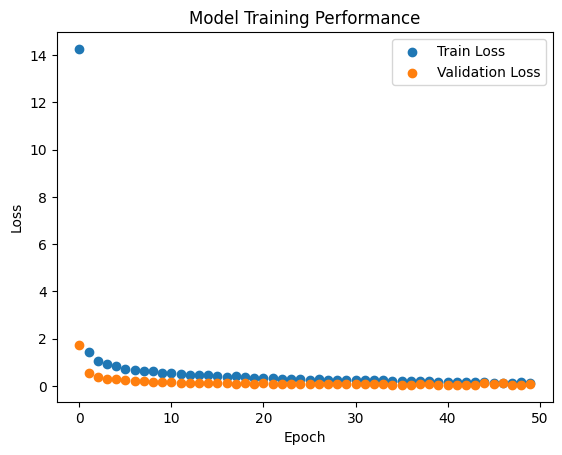

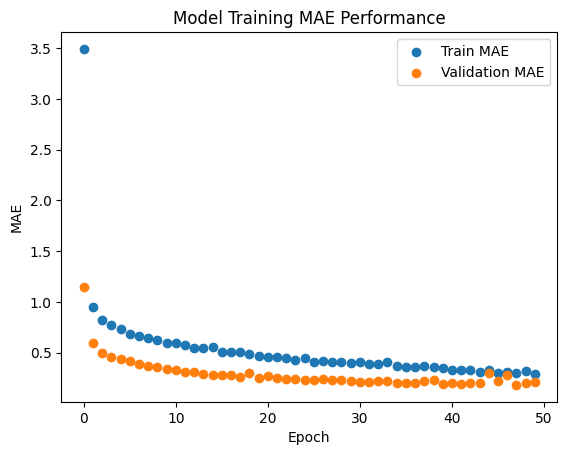

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_processed, y_train,  # Use preprocessed training data
    validation_data=(X_test_processed, y_test),  # Use preprocessed test data
    epochs=50,
    batch_size=16,
    verbose=1
)

import matplotlib.pyplot as plt

plt.scatter(range(len(history.history['loss'])), history.history['loss'], label='Train Loss')
plt.scatter(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Training Performance')
plt.show()

plt.scatter(range(len(history.history['mae'])), history.history['mae'], label='Train MAE')
plt.scatter(range(len(history.history['val_mae'])), history.history['val_mae'], label='Validation MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Model Training MAE Performance')
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

loss, mae = model.evaluate(X_test_processed, y_test, verbose=0) # Use preprocessed test data
print(f"Mean Absolute Error on test set: {mae:.2f}")

y_pred = model.predict(X_test_processed) # Use preprocessed test data
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared on test set: {r2:.2f}")
print(f"Mean Squared Error on test set: {mse:.2f}")

Mean Absolute Error on test set: 0.17
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
R-squared on test set: 0.89
Mean Squared Error on test set: 0.04


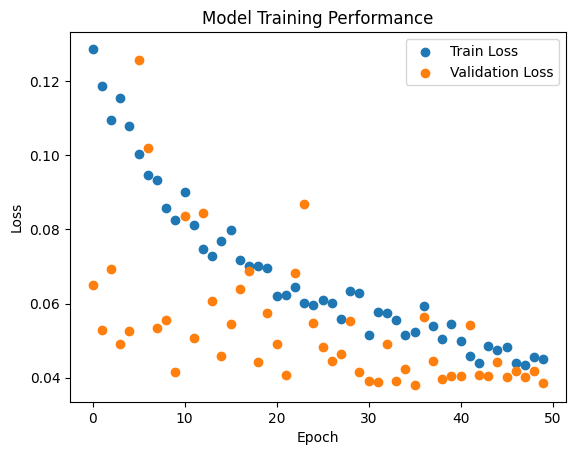

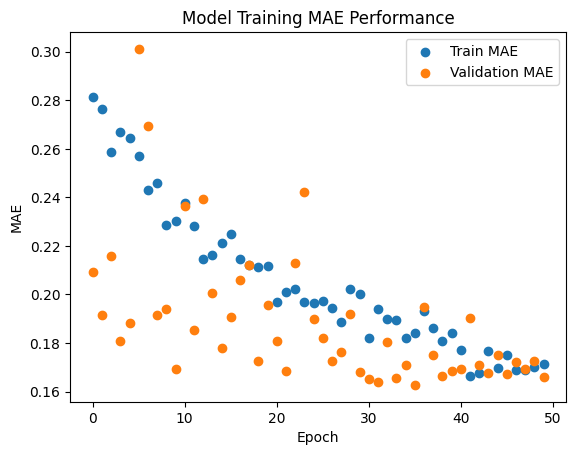

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(range(len(history.history['loss'])), history.history['loss'], label='Train Loss')
plt.scatter(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Training Performance')
plt.show()

plt.scatter(range(len(history.history['mae'])), history.history['mae'], label='Train MAE')
plt.scatter(range(len(history.history['val_mae'])), history.history['val_mae'], label='Validation MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Model Training MAE Performance')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train) # Use preprocessed training data

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_processed) # Use preprocessed test data

# Evaluate the Linear Regression model
r2_linear = r2_score(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)

print("Linear Regression Model Performance:")
print(f"R-squared on test set: {r2_linear:.2f}")
print(f"Mean Absolute Error on test set: {mae_linear:.2f}")
print(f"Mean Squared Error on test set: {mse_linear:.2f}")

# Compare with the Neural Network Model performance (from previous output)
print("\nNeural Network Model Performance:")
print(f"R-squared on test set: {r2:.2f}")
print(f"Mean Absolute Error on test set: {mae:.2f}")
print(f"Mean Squared Error on test set: {mse:.2f}")

Linear Regression Model Performance:
R-squared on test set: 0.90
Mean Absolute Error on test set: 0.16
Mean Squared Error on test set: 0.03

Neural Network Model Performance:
R-squared on test set: 0.89
Mean Absolute Error on test set: 0.17
Mean Squared Error on test set: 0.04


### Actual vs. Predicted Values and Residuals Plots

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


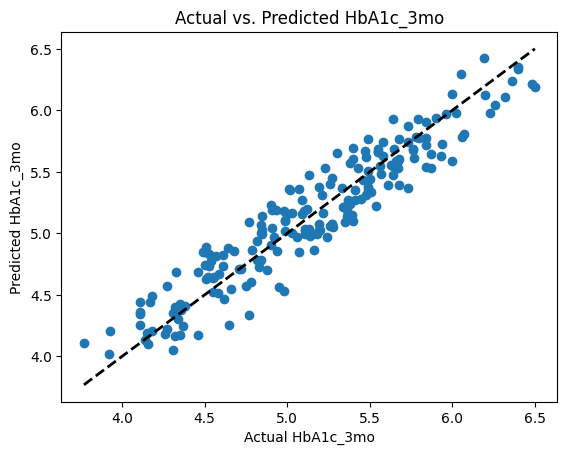

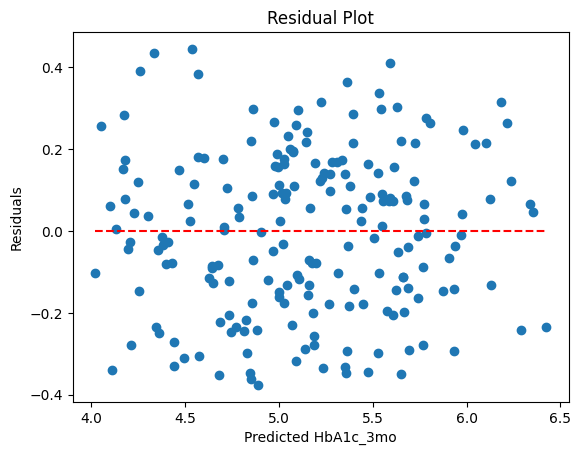

In [ ]:
# Get predictions on the test set
y_pred = model.predict(X_test_processed).flatten()

# Create a scatter plot of actual vs. predicted values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual HbA1c_3mo')
plt.ylabel('Predicted HbA1c_3mo')
plt.title('Actual vs. Predicted HbA1c_3mo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Add a diagonal line
plt.show()

# Calculate residuals
residuals = y_test - y_pred

# Create a scatter plot of residuals
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted HbA1c_3mo')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), color='red', linestyle='--') # Add a horizontal line at 0
plt.show()

In [ ]:
# Example of sample data (replace with your desired values)
# Make sure the order of features matches the training data
sample_data = {
    'Patient_ID': [51],
    'Age': [45],
    'Height_cm': [170],
    'Weight_kg': [75],
    'Work_Hours_per_Week': [40],
    'Work_Stress_Level': ['Low'],
    'Healthcare_Access': ['Good'],
    'Health_Insurance': ['Yes'],
    'Steps_per_day': [8000],
    'Sleep_hours': [7.0],
    'Diet_score': [6],
    'Heart_rate': [70],
    'Glucose_level': [100],
    'Blood_pressure_sys': [120],
    'Blood_pressure_dia': [80],
    'Cholesterol': [200],
    'BMI': [25.9],
    'Exercise_days': [3],
    'HbA1c (%)': [5.5],
}

# Define the columns that should NOT be dropped (i.e., the columns expected in X)
columns_to_keep = ['Patient_ID', 'Age', 'Height_cm', 'Weight_kg', 'Work_Hours_per_Week',
                   'Work_Stress_Level', 'Healthcare_Access', 'Health_Insurance',
                   'Steps_per_day', 'Sleep_hours', 'Diet_score', 'Heart_rate',
                   'Glucose_level', 'Blood_pressure_sys', 'Blood_pressure_dia',
                   'Cholesterol', 'BMI', 'Exercise_days', 'HbA1c (%)']

# Create the sample DataFrame with only the columns to keep
sample_df = pd.DataFrame({col: sample_data[col] for col in columns_to_keep})


# Ensure the columns are in the same order as the training data
sample_df = sample_df[X.columns]

# Use the fitted preprocessor to transform the sample data
sample_processed = preprocessor.transform(sample_df)

# Make a prediction
predicted_hba1c = model.predict(sample_processed)

print(f"Predicted HbA1c_3mo: {predicted_hba1c[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted HbA1c_3mo: 5.40


In [ ]:
import joblib
import tensorflow as tf

# Save preprocessor
joblib.dump(preprocessor, "health_preprocessor.pkl")

# Save deep learning model
model.save("health_model.h5")

print("✅ Files saved: health_model.h5 and health_preprocessor.pkl")


✅ Files saved: health_model.h5 and health_preprocessor.pkl
